### Data Dictionaries

In [2]:
users_dictionary

,id (Primary Key),Unique identifier for each user.
0,current_age,Current age of the user.
1,retirement_age,Declared retirement age of the user.
2,birth_year,Year of birth for the user.
3,birth_month,Month of birth for the user.
4,gender,Gender of the user ( male or female).
5,address,Residential address of the user.
6,latitude,Latitude of the user’s residence.
7,longitude,Longitude of the user’s residence.
8,per_capita_income,Per capita income of the user.
9,yearly_income,Total yearly income of the user.


In [3]:
trans_dictionary

,id (Primary Key),Unique identifier for each transaction.
0,date,Date of the transaction.
1,client_id (Foreign Key to users_data.id),Identifier linking the transaction to the user in the users_data table.
2,card_id (Foreign Key to cards_data.id),Identifier linking the transaction to the respective card in the cards_data table.
3,amount,Transaction amount in the respective currency.
4,use_chip,Boolean/Flag indicating if the chip was used during the transaction.
5,merchant_id,Unique identifier of the merchant.
6,merchant_city,City where the merchant is located.
7,merchant_state,State where the merchant is located.
8,zip,ZIP code of the merchant's location.
9,mcc (Foreign Key to mcc_codes.mcc_id),Merchant Category Code representing the type of merchant or transaction.


In [4]:
cards_dictionary

,id (Primary Key),Unique identifier for each credit card.
0,client_id (Foreign Key to users_data.id),Identifier linking the card to its owner in the users_data table.
1,card_brand,"Brand or issuer of the credit card (e.g., Visa, Mastercard)."
2,card_type,"Type/category of the card (e.g., debit, credit, etc.)."
3,card_number,Unique number on the credit card.
4,expires,Expiry date of the credit card.
5,cvv,Security code of the card.
6,has_chip,Boolean/Flag indicating if the card has an EMV chip.
7,num_cards_issued,Total number of cards issued for the same account.
8,credit_limit,Credit limit assigned to the card.
9,acct_open_date,Date the credit card account was opened.


In [5]:
mcc_dictionary

,mcc_id (Primary Key),Unique identifier for each Merchant Category Code.
0,Description,"Description of the merchant category (e.g., grocery, travel, entertainment)."


### Exploration: Structures and Information

**The following function makes it easier way to get preliminary information about our four dataframes.**

In [6]:
def preview_df(df, name="DATAFRAME", head_n=5):
    print(f"\n{'='*50}")
    print(f"{name.upper()}")
    print(f"{'='*50}")
    
    # Shape
    print(f"\nShape: {df.shape}")
    
    # Info (cleaner: don't wrap in print)
    print("\nInfo:")
    df.info()
    
    # Missing values
    print("\nMissing Values:")
    display(df.isna().sum())
    
    # Duplicates
    print(f"\nDuplicate Rows: {df.duplicated().sum()}")
    
    # Describe (include categorical too)
    print("\nSummary Statistics:")
    display(df.describe().T)
    
    # Head
    print(f"\nFirst {head_n} rows:")
    display(df.head(head_n))

### Users Data EDA

In [7]:
preview_df(users_data)


DATAFRAME

Shape: (2000, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   int64  
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   object 
 6   address            2000 non-null   object 
 7   latitude           2000 non-null   object 
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   object 
 10  yearly_income      2000 non-null   object 
 11  total_debt         2000 non-null   object 
 12  credit_score       2000 non-null   int64  
 13  num_credit_cards   2000 non-null   int64  
dtypes: float64(1), int64(7), object(6)
memory usage: 218.9+ KB

Missing Values:


id                   0
current_age          0
retirement_age       0
birth_year           0
birth_month          0
gender               0
address              0
latitude             0
longitude            0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
num_credit_cards     0
dtype: int64


Duplicate Rows: 0

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
id,2000.0,999.500000,577.494589,0.00,499.750,999.50,1499.25,1999.00
current_age,2000.0,45.391500,18.414092,18.00,30.000,44.00,58.00,101.00
retirement_age,2000.0,66.237500,3.628867,50.00,65.000,66.00,68.00,79.00
birth_year,2000.0,1973.803000,18.421234,1918.00,1961.000,1975.00,1989.00,2002.00
birth_month,2000.0,6.439000,3.565338,1.00,3.000,7.00,10.00,12.00
longitude,2000.0,-91.554765,16.283293,-159.41,-97.395,-86.44,-80.13,-68.67
credit_score,2000.0,709.734500,67.221949,480.00,681.000,711.50,753.00,850.00
num_credit_cards,2000.0,3.073000,1.637379,1.00,2.000,3.00,4.00,9.00



First 5 rows:


,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1


**1. There are no missing or duplicated values.**

**2. A customer can own 1-9 credit cars.**

**3. The oldest current age is 101 years old. A possible anomaly.**
**4. These three columns: per capita income, yearly income, and total debt, are formatted as strings. I will change them to float.**

### Users Data Cleaning

users_data['per_capita_income'] = users_data['per_capita_income'].str.replace('$','').astype(float)

users_data['yearly_income'] = users_data['yearly_income'].str.replace('$','').astype(float)

users_data['total_debt'] = users_data['total_debt'].str.replace('$','').astype(float)

In [76]:
users_data["latitude"] = users_data["latitude"].astype(str).str.strip()
latitude_clean = pd.to_numeric(users_data["latitude"], errors="coerce")
latitude_clean.isna().sum()


np.int64(45)

In [77]:
users_data.loc[latitude_clean.isna(), ["address", "latitude", "longitude"]]

,address,latitude,longitude
41,829 Birch Boulevard,2024-08-27 00:00:00,-97.39
44,1942 Rose Avenue,2024-01-29 00:00:00,-81.00
47,2468 Spruce Drive,2024-07-28 00:00:00,-81.34
66,79 South Boulevard,2024-05-29 00:00:00,-97.44
98,2302 Catherine Lane,2024-02-26 00:00:00,-80.16
112,335 Valley Stream Boulevard,2024-05-29 00:00:00,-97.44
132,3472 11th Avenue,2024-05-28 00:00:00,-81.37
148,387 Third Boulevard,2024-05-31 00:00:00,-111.06
254,857 Jefferson Avenue,2024-07-29 00:00:00,-98.11
322,3031 Essex Street,2024-02-28 00:00:00,-82.59


In [78]:
users_data["latitude"] = latitude_clean

In [81]:

users_data.head(5)

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,37891.0,77254.0,191349.0,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,22681.0,33483.0,196.0,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,163145.0,249925.0,202328.0,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,53797.0,109687.0,183855.0,675,1


## Transactions EDA

In [9]:
preview_df(transactions_data)


DATAFRAME

Shape: (157224, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157224 entries, 0 to 157223
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              157224 non-null  int64         
 1   date            157224 non-null  datetime64[ns]
 2   client_id       157224 non-null  int64         
 3   card_id         157224 non-null  int64         
 4   amount          157224 non-null  float64       
 5   use_chip        157224 non-null  object        
 6   merchant_id     157224 non-null  int64         
 7   merchant_city   157224 non-null  object        
 8   merchant_state  139303 non-null  object        
 9   zip             138118 non-null  float64       
 10  mcc             157224 non-null  int64         
 11  errors          2738 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(5), object(4)
memory usage: 14.4+ MB

Missing Values:


id                     0
date                   0
client_id              0
card_id                0
amount                 0
use_chip               0
merchant_id            0
merchant_city          0
merchant_state     17921
zip                19106
mcc                    0
errors            154486
dtype: int64


Duplicate Rows: 0

Summary Statistics:


,count,mean,min,25%,50%,75%,max,std
id,157224.0,21319932.064087,18881583.0,20099289.25,21312982.5,22538005.5,23761821.0,1409058.325944
date,157224,2023-06-01 22:41:27.713326080,2022-01-01 01:43:00,2022-09-15 18:47:45,2023-05-31 11:01:30,2024-02-14 19:34:30,2024-10-31 23:06:00,NaN
client_id,157224.0,244.47017,0.0,114.0,235.0,373.0,497.0,147.294551
card_id,157224.0,3472.708403,19.0,2426.0,3581.0,4841.0,6133.0,1638.18696
amount,157224.0,43.724136,-500.0,8.59,31.14,66.2325,1911.54,81.088546
merchant_id,157224.0,47876.177066,37.0,25887.0,45453.0,68671.0,100340.0,26009.159493
zip,138118.0,52374.559732,1010.0,28657.0,48235.0,78413.0,99829.0,29720.51962
mcc,157224.0,5581.750776,1711.0,5300.0,5499.0,5812.0,9402.0,876.443164



First 5 rows:


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,23565628,2024-09-20 08:43:00,44,5748,60.00,Chip Transaction,27092,Medford,OR,97501.0,4829,Bad PIN
1,23252317,2024-07-15 21:19:00,327,3063,20.00,Chip Transaction,27092,Bloomfield,CT,6002.0,4829,Bad PIN
2,22878540,2024-04-27 18:21:00,233,1297,0.00,Chip Transaction,27092,Minneapolis,MN,55433.0,4829,Bad PIN
3,23402443,2024-08-16 14:44:00,114,3398,92.00,Chip Transaction,59935,North Hollywood,CA,91606.0,5499,Bad PIN
4,23267370,2024-07-19 08:16:00,157,1052,23.66,Chip Transaction,59935,Perris,CA,92571.0,5499,Bad PIN


**There are many missing values noted in columns: merchant state, zip, and errors. From the transactions dictionary, we know that not all transactions have errors. But why the null in merchant state and zip if merchant city has no nulls?**

In [10]:
missing_location = transactions_data[transactions_data['merchant_state'].isna() & transactions_data['zip'].isna()]

missing_location['merchant_id'].nunique()

102

In [11]:
missing_location['merchant_city'].value_counts()

merchant_city
ONLINE    17921
Name: count, dtype: int64

**Interpretation:**

**The missing merchant state and zip are exclusively associated with online transactions, where physical location data is not applicable. Therefore, I will not be replacing null values.**

### Cards EDA

In [12]:
preview_df(cards_data)


DATAFRAME

Shape: (6146, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     6146 non-null   int64         
 1   client_id              6146 non-null   int64         
 2   card_brand             6146 non-null   object        
 3   card_type              6146 non-null   object        
 4   card_number            6146 non-null   int64         
 5   expires                6146 non-null   datetime64[ns]
 6   cvv                    6146 non-null   int64         
 7   has_chip               6146 non-null   object        
 8   num_cards_issued       6146 non-null   int64         
 9   credit_limit           6146 non-null   object        
 10  acct_open_date         6146 non-null   datetime64[ns]
 11  year_pin_last_changed  6146 non-null   int64         
dtypes: datetime64[ns](2), int

id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
dtype: int64


Duplicate Rows: 0

Summary Statistics:


,count,mean,min,25%,50%,75%,max,std
id,6146.0,3072.5,0.0,1536.25,3072.5,4608.75,6145.0,1774.341709
client_id,6146.0,994.939636,0.0,492.25,992.0,1495.0,1999.0,578.614626
card_number,6146.0,4820425803848952.0,300105541992311.0,4486365176018947.5,5108957434464470.0,5585237469514462.0,6997197066610970.0,1328582205754832.75
expires,6146,2020-10-08 06:30:06.443215360,1997-07-01 00:00:00,2020-02-01 00:00:00,2021-09-01 00:00:00,2023-05-01 00:00:00,2024-12-01 00:00:00,NaN
cvv,6146.0,506.220794,0.0,257.0,516.5,756.0,999.0,289.431123
num_cards_issued,6146.0,1.503091,1.0,1.0,1.0,2.0,3.0,0.519191
acct_open_date,6146,2011-01-15 12:55:31.727953152,1991-01-01 00:00:00,2006-10-01 00:00:00,2010-02-15 00:00:00,2016-05-01 00:00:00,2020-02-01 00:00:00,NaN
year_pin_last_changed,6146.0,2013.436707,2002.0,2010.0,2013.0,2017.0,2020.0,4.270699



First 5 rows:


,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed
0,4524,825,Visa,Debit,4344676511950440,2022-12-01,623,YES,2,$24295,2002-09-01,2008
1,2731,825,Visa,Debit,4956965974959980,2020-12-01,393,YES,2,$21968,2014-04-01,2014
2,3701,825,Visa,Debit,4582313478255490,2024-02-01,719,YES,2,$46414,2003-07-01,2004
3,42,825,Visa,Credit,4879494103069050,2024-08-01,693,NO,1,$12400,2003-01-01,2012
4,4659,825,Mastercard,Debit (Prepaid),5722874738736010,2009-03-01,75,YES,1,$28,2008-09-01,2009


### Cards Data Cleaning
**Changing the credit limit from string to float.**

In [25]:
cards_data['credit_limit'] = cards_data['credit_limit'].str.replace('$','').astype(float)
cards_data.head()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed
0,4524,825,Visa,Debit,4344676511950440,2022-12-01,623,YES,2,24295.0,2002-09-01,2008
1,2731,825,Visa,Debit,4956965974959980,2020-12-01,393,YES,2,21968.0,2014-04-01,2014
2,3701,825,Visa,Debit,4582313478255490,2024-02-01,719,YES,2,46414.0,2003-07-01,2004
3,42,825,Visa,Credit,4879494103069050,2024-08-01,693,NO,1,12400.0,2003-01-01,2012
4,4659,825,Mastercard,Debit (Prepaid),5722874738736010,2009-03-01,75,YES,1,28.0,2008-09-01,2009


**1. There are no missing or duplicated values.**
**2. A client can have more than 1 card from either brand.**

### MCC Codes EDA

In [14]:
preview_df(mcc_codes)


DATAFRAME

Shape: (109, 2)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   mcc_id       109 non-null    int64 
 1   Description  109 non-null    object
dtypes: int64(1), object(1)
memory usage: 1.8+ KB

Missing Values:


mcc_id         0
Description    0
dtype: int64


Duplicate Rows: 0

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
mcc_id,109.0,5311.165138,1747.760406,1711.0,3684.0,5310.0,5977.0,9402.0



First 5 rows:


,mcc_id,Description
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"
3,5411,"Grocery Stores, Supermarkets"
4,4784,Tolls and Bridge Fees


## EDA PLOTTING

To-Do:
1. Online vs Offline transactions
2. card brand vs card type
3. current age vs retirement age
4. errors
5. credit score
6. total debt
7. income ratio

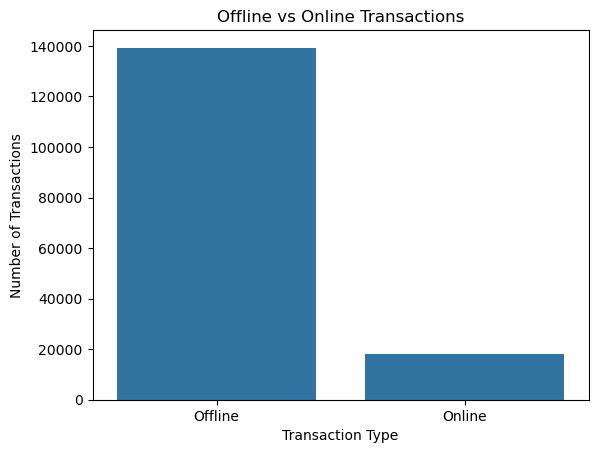

In [15]:
online_offline = np.where(
    transactions_data['merchant_city'] == 'ONLINE',
    'Online',
    'Offline'
)

plt.figure()
sns.countplot(x=online_offline)
plt.title('Offline vs Online Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.show()

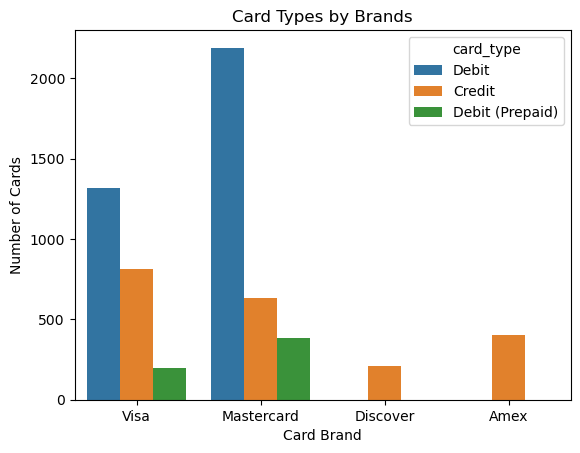

In [16]:
plt.figure()
sns.countplot(data=cards_data, x='card_brand', hue='card_type')
plt.title('Card Types by Brands')
plt.xlabel('Card Brand')
plt.ylabel('Number of Cards')
plt.show()

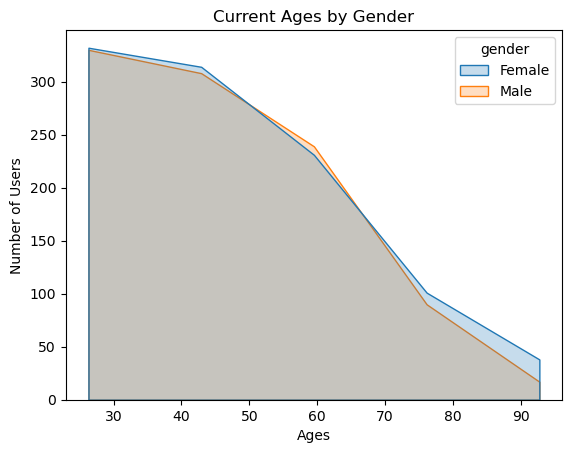

In [17]:
plt.figure()
sns.histplot(data=users_data, x='current_age', hue='gender', element='poly', bins=5)
plt.title('Current Ages by Gender')
plt.xlabel('Ages')
plt.ylabel('Number of Users')
plt.show()

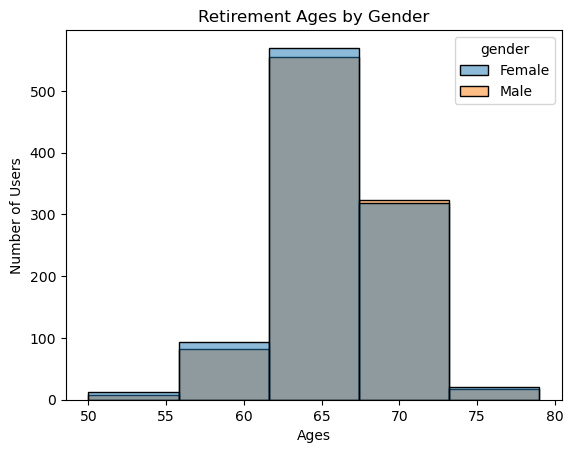

In [18]:
plt.figure()
sns.histplot(data=users_data, x='retirement_age', hue='gender', element='bars', bins=5)
plt.title('Retirement Ages by Gender')
plt.xlabel('Ages')
plt.ylabel('Number of Users')
plt.show()

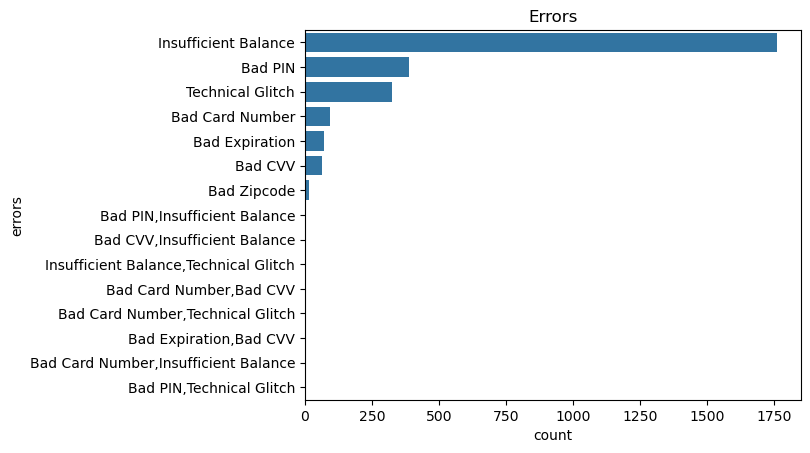

In [19]:
plt.figure()
sns.countplot(data=transactions_data, y='errors', order=transactions_data['errors'].value_counts().index)
plt.title('Errors')
plt.show()

**Quite a lot of peaople not knowing their current balance.**

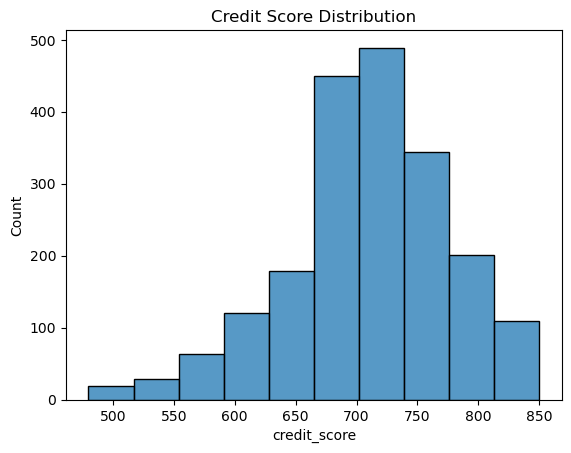

In [20]:
plt.figure()
sns.histplot(data=users_data, x='credit_score', bins=10)
plt.title('Credit Score Distribution')
plt.show()

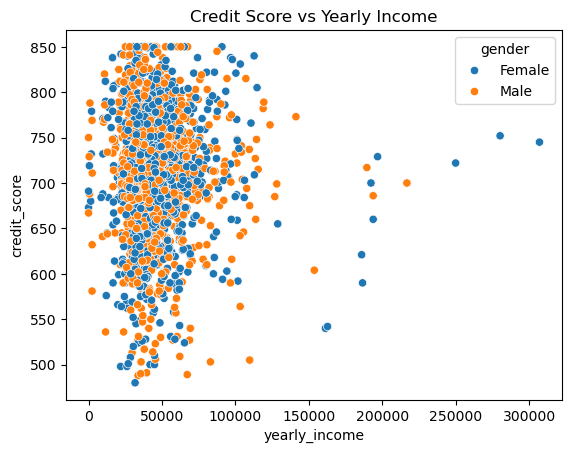

In [56]:
plt.figure()
sns.scatterplot(data=users_data, x='yearly_income', y='credit_score', hue='gender')
plt.title('Credit Score vs Yearly Income')
plt.show()

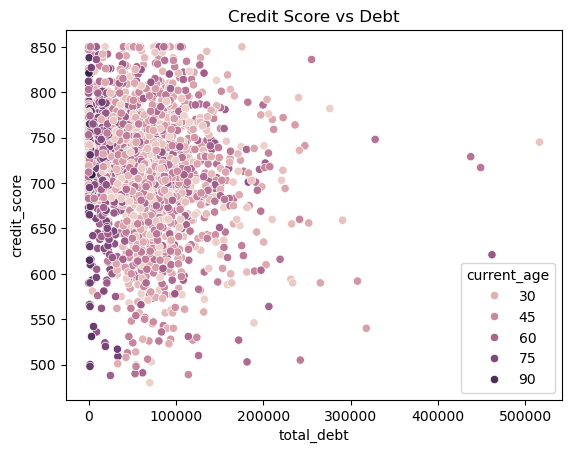

In [57]:
plt.figure()
sns.scatterplot(data=users_data, x='total_debt', y='credit_score', hue='current_age')
plt.title('Credit Score vs Debt')
plt.show()

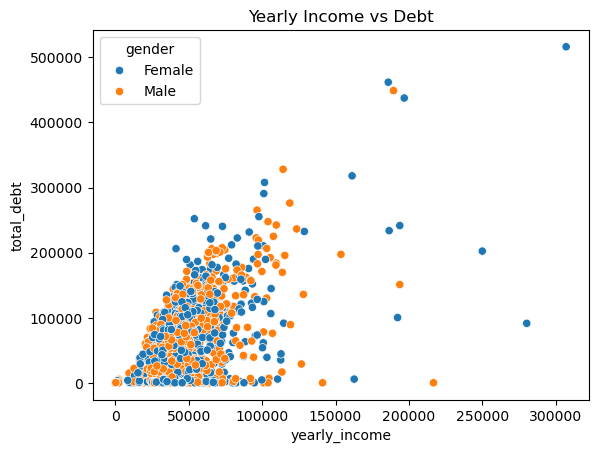

In [58]:
plt.figure()
sns.scatterplot(data=users_data, x='yearly_income', y='total_debt', hue='gender')
plt.title('Yearly Income vs Debt')
plt.show()

users_data.to_csv('users_data.csv', index=False)
transactions_data.to_csv('transactions_data.csv', index=False)
cards_data.to_csv('cards_data.csv', index=False)
mcc_codes.to_csv('mcc_codes.csv', index=False)

In [82]:
users_data.to_csv('users_data.csv', index=False)